--- INFORMASI UKURAN DATASET AWAL ---
Total Data: 2000 baris dan 15 kolom.

Jumlah Missing Value per Kolom:
post_id            0
platform           0
content_type       0
topic              0
language           0
region             0
post_datetime      0
hashtags           0
views              0
likes              0
comments           0
shares             0
engagement_rate    0
sentiment_score    0
is_viral           0
dtype: int64

[INFO] Tidak ditemukan data duplikat. Dataset aman.

--- TABEL HASIL SCALE (5 BARIS PERTAMA) ---


,views,likes,comments,shares
0,-0.605709,-0.850169,-0.622809,-1.691951
1,-0.538117,-0.930792,-0.935428,0.170658
2,-0.996395,-1.087830,1.552985,-0.200133
3,0.303995,0.580262,-1.664135,0.337832
4,-0.338513,-0.318548,-1.349367,1.143505


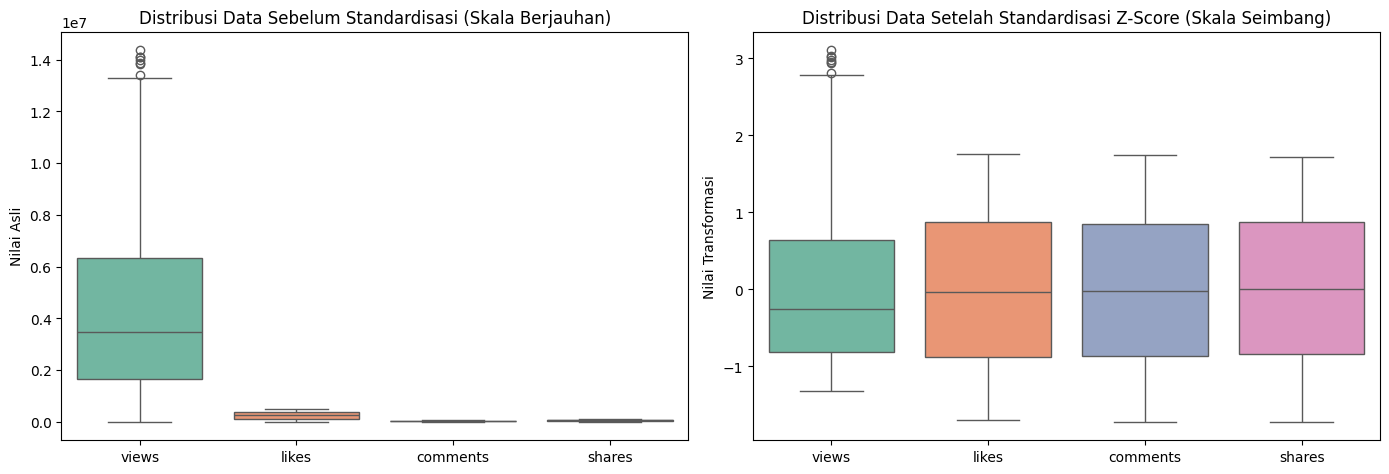

In [17]:
# ==========================================
# DATA PREPROCESSING & STANDARDIZASI
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Memuat Dataset
df = pd.read_csv('social_media_viral_content_dataset.csv')
print("--- INFORMASI UKURAN DATASET AWAL ---")
print(f"Total Data: {df.shape[0]} baris dan {df.shape[1]} kolom.\n")

# Pembersihan Data Duplikat & Missing Value
print("Jumlah Missing Value per Kolom:")
print(df.isnull().sum())

if df.duplicated().sum() > 0:
    print(f"\n[INFO] Menghapus {df.duplicated().sum()} data duplikat...")
    df = df.drop_duplicates()
else:
    print("\n[INFO] Tidak ditemukan data duplikat. Dataset aman.")

# Fitur Numerik Khusus K-Means
features_clustering = ['views', 'likes', 'comments', 'shares']
X_clustering = df[features_clustering]

# Standardisasi Data (Z-Score) & Pembuatan Tabel Hasil Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clustering)

df_scaled = pd.DataFrame(X_scaled, columns=features_clustering)

print("\n--- TABEL HASIL SCALE (5 BARIS PERTAMA) ---")
display(df_scaled.head()) 

# VISUALISASI SEBELUM VS SESUDAH STANDARDIZASI
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot sebelum standardisasi (Skala Asli)
sns.boxplot(data=X_clustering, ax=ax1, palette="Set2")
ax1.set_title("Distribusi Data Sebelum Standardisasi (Skala Berjauhan)")
ax1.set_ylabel("Nilai Asli")

# Plot sesudah standardisasi (Skala Seimbang)
sns.boxplot(data=df_scaled, ax=ax2, palette="Set2")
ax2.set_xticks(np.arange(len(features_clustering)))
ax2.set_xticklabels(features_clustering)
ax2.set_title("Distribusi Data Setelah Standardisasi Z-Score (Skala Seimbang)")
ax2.set_ylabel("Nilai Transformasi")

plt.tight_layout()
plt.show()

--- TABEL NILAI SSE UNTUK TIAP NILAI K ---


,Jumlah Cluster (k),Nilai SSE (Inertia)
0,1,8000.00
1,2,5453.04
2,3,4512.43
3,4,3861.91
4,5,3364.14
5,6,2954.80
6,7,2646.67
7,8,2396.12
8,9,2201.18
9,10,2040.00


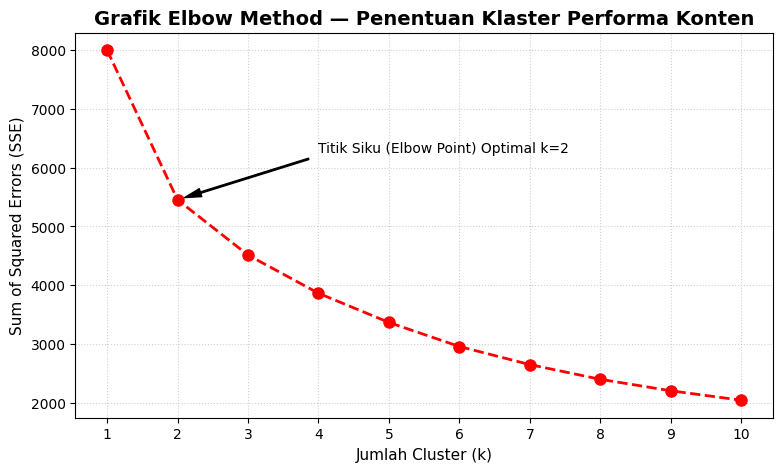

In [18]:
# =====================================================================
# ELBOW METHOD
# =====================================================================
from sklearn.cluster import KMeans

# Inisialisasi list untuk menyimpan nilai SSE (Inertia)
sse_list = []
K_range = range(1, 11)

# Perulangan untuk menghitung nilai SSE pada setiap nilai K
for k_val in K_range:
    km = KMeans(n_clusters=k_val, random_state=42, n_init=10)
    km.fit(df_scaled)
    sse_list.append(km.inertia_)

# Membuat Tabel Dataframe Hasil Nilai SSE
df_elbow_results = pd.DataFrame({
    'Jumlah Cluster (k)': list(K_range),
    'Nilai SSE (Inertia)': sse_list
})

print("--- TABEL NILAI SSE UNTUK TIAP NILAI K ---")
display(df_elbow_results.round(2))

# Visualisasi Grafik Elbow Method
plt.figure(figsize=(9, 5))
plt.plot(K_range, sse_list, marker='o', color='red', linestyle='--', linewidth=2, markersize=8)
plt.annotate('Titik Siku (Elbow Point) Optimal k=2', 
             xy=(2, sse_list[1]), 
             xytext=(4, sse_list[1] + (max(sse_list)*0.1)),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6))

plt.title("Grafik Elbow Method — Penentuan Klaster Performa Konten", fontsize=14, fontweight='bold')
plt.xlabel("Jumlah Cluster (k)", fontsize=11)
plt.ylabel("Sum of Squared Errors (SSE)", fontsize=11)
plt.xticks(list(K_range))
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

          EKSEKUSI K-MEANS BERHASIL               
Sebaran Jumlah Objek Konten per Klaster:
cluster_performa
2    1090
1     910
Name: count, dtype: int64


--- TABEL RATA-RATA KARAKTERISTIK (CENTROID) TIAP KLASTER ---


,views,likes,comments,shares
cluster_performa,,,,
1,6966410.32,378353.58,24377.27,49555.07
2,2046133.71,134272.23,25128.94,50255.83


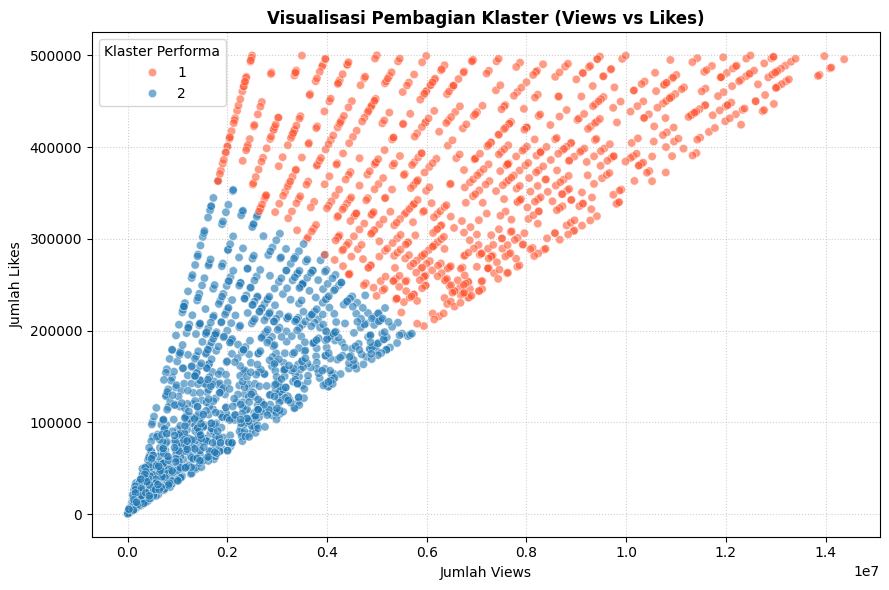

In [19]:
# =====================================================================
# K-MEANS CLUSTERING & PROFILING CENTROID
# =====================================================================
from sklearn.cluster import KMeans

# Menjalankan Algoritma K-Means Final
k_optimal = 2
kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)

# Memasukkan label klaster ke dataframe asli (ditambah 1 agar kelompok bernilai 1 dan 2)
df['cluster_performa'] = kmeans.fit_predict(df_scaled) + 1

print("==================================================")
print("          EKSEKUSI K-MEANS BERHASIL               ")
print("==================================================")
print("Sebaran Jumlah Objek Konten per Klaster:")
print(df['cluster_performa'].value_counts())
print("\n")

# Profiling Centroid
profil_centroid = df.groupby('cluster_performa')[features_clustering].mean()
print("--- TABEL RATA-RATA KARAKTERISTIK (CENTROID) TIAP KLASTER ---")
display(profil_centroid.round(2))
print("\n")


# Visualisasi Hasil Klastering
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df, 
    x='views', 
    y='likes', 
    hue='cluster_performa', 
    palette=['#FF5733', '#1f77b4'], 
    alpha=0.6
)

plt.title("Visualisasi Pembagian Klaster (Views vs Likes)", fontsize=12, fontweight='bold')
plt.xlabel("Jumlah Views")
plt.ylabel("Jumlah Likes")
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(title="Klaster Performa")

plt.tight_layout()
plt.show()

--- STRUKTUR FITUR BARU SELEPAS ONE-HOT ENCODING ---
Total Kolom Prediktor Biner: 14 kolom
['topic_Education', 'topic_Entertainment', 'topic_Lifestyle', 'topic_Politics', 'topic_Sports', 'topic_Technology', 'platform_Instagram', 'platform_TikTok', 'platform_X', 'platform_YouTube Shorts', 'content_type_carousel', 'content_type_image', 'content_type_text', 'content_type_video']


          PROSES SPLIT DATA SELESAI               
Ukuran Data Training (80%) : 1600 baris
Ukuran Data Testing (20%)  : 400 baris



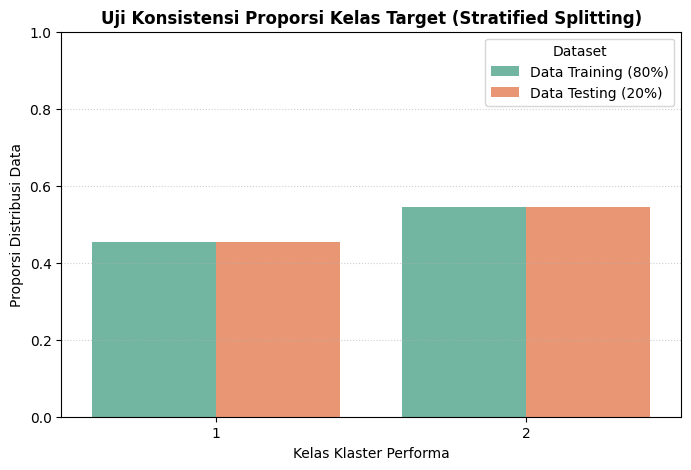

In [20]:
# =====================================================================
# FEATURE SELECTION, ENCODING, & DATA SPLITTING
# =====================================================================
from sklearn.model_selection import train_test_split

# Menentukan Fitur Prediktor (X) dan Target (Y)
categorical_features = ['topic', 'platform', 'content_type']
y = df['cluster_performa']

# Transformasi Variabel Kategorikal menjadi Biner via One-Hot Encoding
X_encoded = pd.get_dummies(df[categorical_features], drop_first=False)

# Mengubah nilai Boolean (True/False) hasil get_dummies menjadi angka biner (1/0)
X_encoded = X_encoded.astype(int)

print("--- STRUKTUR FITUR BARU SELEPAS ONE-HOT ENCODING ---")
print(f"Total Kolom Prediktor Biner: {X_encoded.shape[1]} kolom")
print(X_encoded.columns.tolist())
print("\n")

# Melakukan Split Data 80% Training dan 20% Testing
# Menggunakan stratify=y agar proporsi kelas 1 dan 2 seimbang di kedua subset data
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print("==================================================")
print("          PROSES SPLIT DATA SELESAI               ")
print("==================================================")
print(f"Ukuran Data Training (80%) : {X_train.shape[0]} baris")
print(f"Ukuran Data Testing (20%)  : {X_test.shape[0]} baris\n")


# Visualisasi Proporsi Kelas Target (Stratified Check)
df_train_prop = y_train.value_counts(normalize=True).to_frame(name='Persentase')
df_train_prop['Dataset'] = 'Data Training (80%)'

df_test_prop = y_test.value_counts(normalize=True).to_frame(name='Persentase')
df_test_prop['Dataset'] = 'Data Testing (20%)'

df_split_check = pd.concat([df_train_prop, df_test_prop]).reset_index()
df_elbow_results.to_csv('elbow_data.csv', index=False)
plt.figure(figsize=(8, 5))
sns.barplot(
    data=df_split_check,
    x='cluster_performa',
    y='Persentase',
    hue='Dataset',
    palette='Set2'
)
plt.title("Uji Konsistensi Proporsi Kelas Target (Stratified Splitting)", fontsize=12, fontweight='bold')
plt.xlabel("Kelas Klaster Performa")
plt.ylabel("Proporsi Distribusi Data")
plt.ylim(0, 1.0)
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.show()

       PERBANDINGAN HASIL AKURASI MODEL           
Akurasi Bernoulli Naïve Bayes : 51.75%
Akurasi Logistic Regression    : 52.75%

--- REPORT KLASIFIKASI NAÏVE BAYES ---
                   precision    recall  f1-score   support

High Performa (1)       0.43      0.19      0.27       182
 Low Performa (2)       0.54      0.79      0.64       218

         accuracy                           0.52       400
        macro avg       0.49      0.49      0.45       400
     weighted avg       0.49      0.52      0.47       400


--- REPORT KLASIFIKASI LOGISTIC REGRESSION ---
                   precision    recall  f1-score   support

High Performa (1)       0.43      0.12      0.19       182
 Low Performa (2)       0.54      0.87      0.67       218

         accuracy                           0.53       400
        macro avg       0.49      0.49      0.43       400
     weighted avg       0.49      0.53      0.45       400



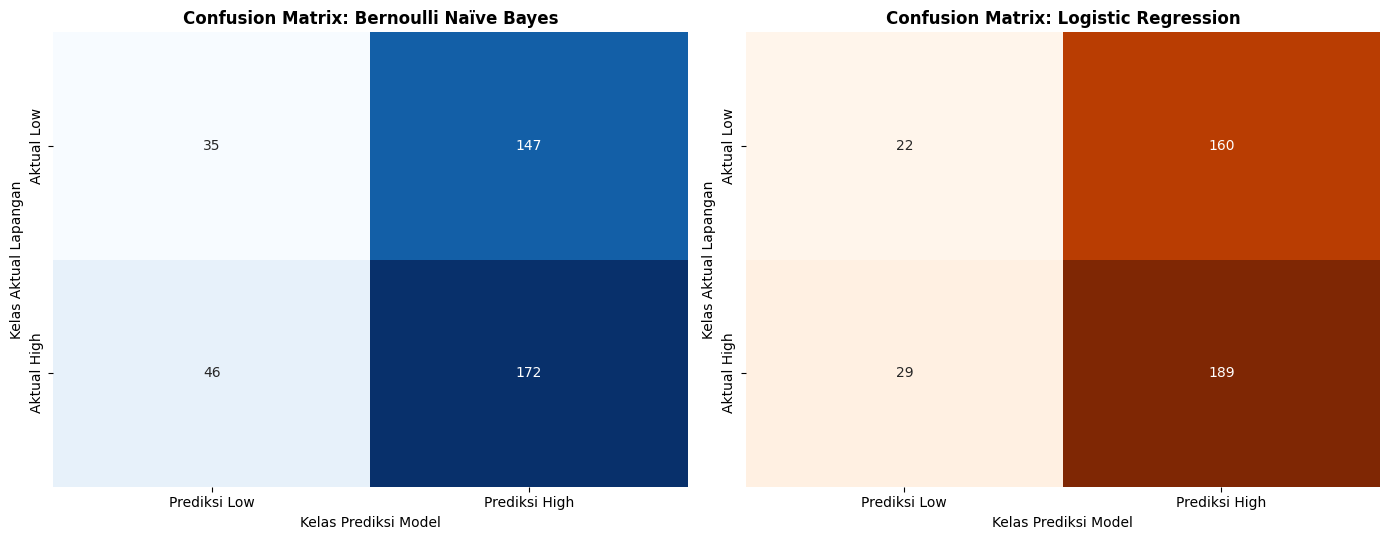


[SUCCESS] Semua model .pkl dan dataset berlabel berhasil diexport ke folder proyek!


In [21]:
# =====================================================================
# MODEL TRAINING, TESTING, COMPARING & CONFUSION MATRIX
# =====================================================================
import joblib
from sklearn.naive_bayes import BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Pelatihan Model 1: Bernoulli Naïve Bayes
nb_model = BernoulliNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)

# Pelatihan Model 2: Logistic Regression
lr_model = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

# =====================================================================
# EVALUASI DAN CETAK METRIK
# =====================================================================
print("==================================================")
print("       PERBANDINGAN HASIL AKURASI MODEL           ")
print("==================================================")
print(f"Akurasi Bernoulli Naïve Bayes : {accuracy_score(y_test, y_pred_nb)*100:.2f}%")
print(f"Akurasi Logistic Regression    : {accuracy_score(y_test, y_pred_lr)*100:.2f}%")
print("==================================================\n")

print("--- REPORT KLASIFIKASI NAÏVE BAYES ---")
print(classification_report(y_test, y_pred_nb, target_names=['High Performa (1)', 'Low Performa (2)']))

print("\n--- REPORT KLASIFIKASI LOGISTIC REGRESSION ---")
print(classification_report(y_test, y_pred_lr, target_names=['High Performa (1)', 'Low Performa (2)']))

# =====================================================================
# COMPARATIVE CONFUSION MATRIX HEATMAP
# =====================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

# Heatmap Confusion Matrix Naïve Bayes
cm_nb = confusion_matrix(y_test, y_pred_nb)
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax1,
            xticklabels=['Prediksi Low', 'Prediksi High'], yticklabels=['Aktual Low', 'Aktual High'])
ax1.set_title("Confusion Matrix: Bernoulli Naïve Bayes", fontsize=12, fontweight='bold')
ax1.set_xlabel("Kelas Prediksi Model")
ax1.set_ylabel("Kelas Aktual Lapangan")

# Heatmap Confusion Matrix Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Oranges', cbar=False, ax=ax2,
            xticklabels=['Prediksi Low', 'Prediksi High'], yticklabels=['Aktual Low', 'Aktual High'])
ax2.set_title("Confusion Matrix: Logistic Regression", fontsize=12, fontweight='bold')
ax2.set_xlabel("Kelas Prediksi Model")
ax2.set_ylabel("Kelas Aktual Lapangan")

plt.tight_layout()
plt.show()

# =====================================================================
# EXPORT ARTIFACTS (.pkl) UNTUK DEPLOYMENT STREAMLIT
# =====================================================================
joblib.dump(nb_model, 'model_naive_bayes.pkl')
joblib.dump(lr_model, 'model_logistic_regression.pkl')
joblib.dump(X_encoded.columns.tolist(), 'X_columns.pkl')

df.to_csv('social_media_with_clusters.csv', index=False)

df_cm = pd.DataFrame({
    'Actual': ['Low', 'Low', 'High', 'High', 'Low', 'Low', 'High', 'High'],
    'Predicted': ['Low', 'High', 'Low', 'High', 'Low', 'High', 'Low', 'High'],
    'Value': [cm_lr[0,0], cm_lr[0,1], cm_lr[1,0], cm_lr[1,1],  # Angka Kotak Matriks Logistic Regression
              cm_nb[0,0], cm_nb[0,1], cm_nb[1,0], cm_nb[1,1]], # Angka Kotak Matriks Naive Bayes
    'Model': ['Logistic Regression']*4 + ['Bernoulli Naive Bayes']*4
})

df_cm.to_csv('confusion_matrix_data.csv', index=False)

print("\n[SUCCESS] Semua model .pkl dan dataset berlabel berhasil diexport ke folder proyek!")